# 20회차 기출문제 해답

## 문제 1

**Data description**

1년치 온도 데이터가 수집되었고, 주어진 설명변수를 이용해서 실제 온도를 예측하는 문제입니다.

-   year: 연도
-   month: 월
-   day: 일
-   week: 요일
-   temp_2: 2일 이전 최대 온도
-   temp_1: 1일 이전 최대 온도
-   average: 최대 온도 평균
-   actual: 실제 최대 온도
-   friend: 친구가 예측한 값, 평균 +- 20 사이의 임의의 숫자


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn import set_config
set_config(display="diagram")

from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.svm import SVR

In [2]:
dat = pd.read_csv('problem1.csv')
dat = dat.drop(['forecast_noaa', 'forecast_acc', 'forecast_under'], axis = 1)

In [3]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     348 non-null    int64  
 1   month    348 non-null    int64  
 2   day      348 non-null    int64  
 3   week     348 non-null    object 
 4   temp_2   348 non-null    int64  
 5   temp_1   348 non-null    int64  
 6   average  348 non-null    float64
 7   actual   348 non-null    int64  
 8   friend   348 non-null    int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 24.6+ KB


In [4]:
dat['date'] = pd.to_datetime(dict(year=dat.year, month=dat.month, day=dat.day))
dat.set_index('date', inplace = True)

**1. 데이터 전처리를 실시하시오(10점).**

-   EDA
-   결측치 처리
-   필요 없는 변수 처리
-   train/test 분리를 어떻게 할지 설명
-   최종 전처리 데이터셋 제시

In [5]:
dat.describe()

,year,month,day,temp_2,temp_1,average,actual,friend
count,348.0,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,2016.0,6.477011,15.514368,62.652299,62.701149,59.760632,62.543103,60.034483
std,0.0,3.498380,8.772982,12.165398,12.120542,10.527306,11.794146,15.626179
min,2016.0,1.000000,1.000000,35.000000,35.000000,45.100000,35.000000,28.000000
25%,2016.0,3.000000,8.000000,54.000000,54.000000,49.975000,54.000000,47.750000
50%,2016.0,6.000000,15.000000,62.500000,62.500000,58.200000,62.500000,60.000000
75%,2016.0,10.000000,23.000000,71.000000,71.000000,69.025000,71.000000,71.000000
max,2016.0,12.000000,31.000000,117.000000,117.000000,77.400000,92.000000,95.000000


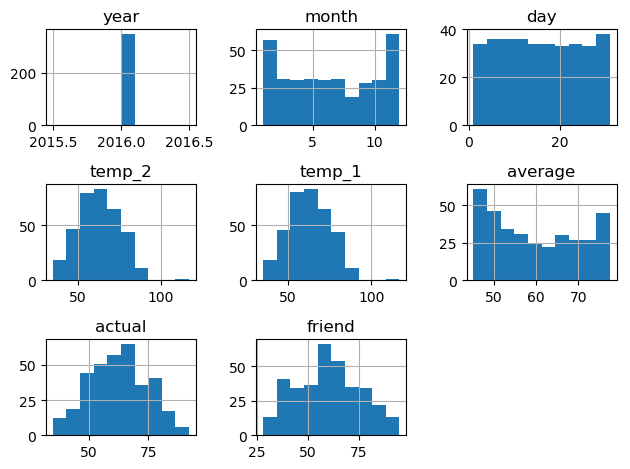

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
dat.hist();
plt.tight_layout();
plt.show();

**결측치 처리**

-   lag 변수(temp_1, temp_2)가 재대로 생성이 되어있는지 확인해볼 필요가 있음

In [7]:
dat.isna().sum()

year       0
month      0
day        0
week       0
temp_2     0
temp_1     0
average    0
actual     0
friend     0
dtype: int64

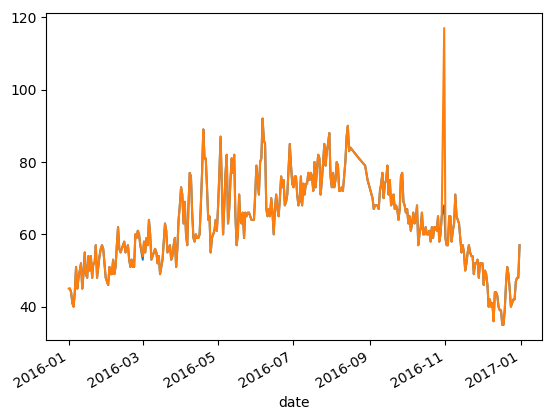

In [8]:
dat['actual'].shift(1).plot()
dat['temp_1'].plot()
plt.show();

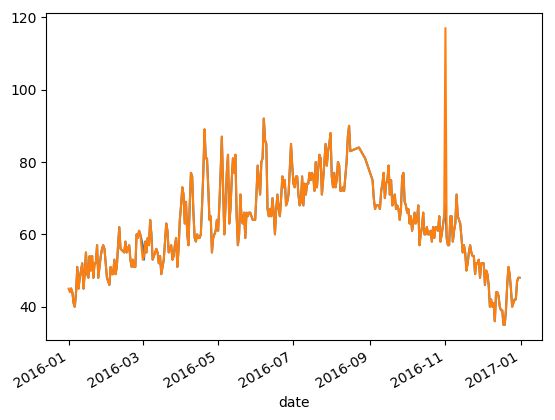

In [9]:
dat['actual'].shift(2).plot()
dat['temp_2'].plot()
plt.show();

-   실제값으로 lag 변수를 생성했을 때 값이 일치하지 않는 것을 확인할 수 있음

**필요없는 변수 처리**

-   temp_1, temp_2변수 제거

-   target 변수를 기준으로 lag변수 재생성

-   friend 변수의 경우 친구가 예측한 값으로 예측에 필요한 정보가 없는 변수이므로 제거

-   year변수는 값이 하나이므로 제거

In [10]:
dat = dat.drop(['temp_1', 'temp_2', 'friend', 'year'], axis = 1)

In [11]:
dat['temp_1'] = dat['actual'].shift(1)
dat['temp_2'] = dat['actual'].shift(2)

In [12]:
dat['temp_1'].head(3)
dat['temp_1'].backfill().head(3)

dat['temp_1'] = dat['temp_1'].backfill()
dat['temp_2'] = dat['temp_2'].backfill()

In [13]:
dat.isna().sum()

month      0
day        0
week       0
average    0
actual     0
temp_1     0
temp_2     0
dtype: int64

In [14]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer, make_column_transformer
num_columns = dat.select_dtypes('number').columns.tolist()
cat_columns = dat.select_dtypes('object').columns.tolist()
num_columns.remove('actual')


cat_preprocess = make_pipeline(
    OneHotEncoder(handle_unknown="ignore", sparse=False)
)

num_preprocess = make_pipeline(
    StandardScaler()
)

preprocess = ColumnTransformer(
    [("num", num_preprocess, num_columns),
    ("cat", cat_preprocess, cat_columns)], 
    remainder='passthrough'
)

preprocess

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('standardscaler',
                                                  StandardScaler())]),
                                 ['month', 'day', 'average', 'temp_1',
                                  'temp_2']),
                                ('cat',
                                 Pipeline(steps=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse=False))]),
                                 ['week'])])

In [15]:
pre_dat = preprocess.fit_transform(dat)
print('preprocess data dim : ', pre_dat.shape)

cat_encoder = preprocess.named_transformers_["cat"]["onehotencoder"]
cat_names = list(cat_encoder.get_feature_names())
full_name = num_columns + cat_names + ['actual']
pd.DataFrame(pre_dat, columns = full_name).head(2)

preprocess data dim :  (348, 13)


C:\Users\alberto\anaconda3\envs\ADP\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


,month,day,average,temp_1,temp_2,x0_Fri,x0_Mon,x0_Sat,x0_Sun,x0_Thurs,x0_Tues,x0_Wed,actual
0,-1.567839,-1.656822,-1.347070,-1.493909,-1.486698,1.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0
1,-1.567839,-1.542671,-1.337558,-1.493909,-1.486698,0.0,0.0,1.0,0.0,0.0,0.0,0.0,44.0


**train/test 분할**

**random split**

-   시간 순으로 나눌지, 혹은 random 하게 나눌지 구분

-   1년 간의 온도는 1\~9월까지는 증가하다가 10\~12월에 감소하는 추세이므로, 시간순으로 나누게되면 모델 성능이 저하될 수 있음

-   따라서 random split 진행

In [16]:
pre_dat = pd.DataFrame(pre_dat, columns = full_name)

In [17]:
from sklearn.model_selection import train_test_split
y = pre_dat['actual']
X = pre_dat.drop(['actual'], axis = 1)

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = 0.2, shuffle = True, random_state = 0)

**1. Random forest 모델을 적합하시오(15점).**

-   예측기준선 수립 및 근거 제시
-   하이퍼 파라미터 튜닝\
-   변수중요도 시각화

예측 기준선을 모델의 유효성을 평가하는 지표로 해석하면, 반응변수의 평균값을 예측 기준선으로 정할 수 있음. 주어진 설명변수를 고려한 모형을 구축했을 때 반응변수의 평균값보다 예측력이 좋지 않다면, 모형을 구축하는 의미가 없기 때문임.

In [18]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
cv = KFold(n_splits = 5, shuffle = True, random_state = 0)

rf_pipe = Pipeline(
    [
        ("regressor", RandomForestRegressor(random_state=42))
    ]
)

RandomForest_param = {'regressor__max_features': np.arange(0.5, 1, 0.1)}

RandomForest_search = GridSearchCV(estimator = rf_pipe, 
                      param_grid = RandomForest_param, 
                      cv = cv,
                      scoring = 'neg_root_mean_squared_error')
RandomForest_search.fit(train_X, train_y)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('regressor',
                                        RandomForestRegressor(random_state=42))]),
             param_grid={'regressor__max_features': array([0.5, 0.6, 0.7, 0.8, 0.9])},
             scoring='neg_root_mean_squared_error')

In [19]:
from sklearn.metrics import mean_squared_error
print('Ramdom forest best parameters : ', RandomForest_search.best_params_)
print('Random forest best score : ', -RandomForest_search.best_score_)

print('예측한계선 RMSE :', mean_squared_error(train_y, dat.iloc[train_X.index, :]['average'], squared = False))

Ramdom forest best parameters :  {'regressor__max_features': 0.6}
Random forest best score :  4.72683507084527
예측한계선 RMSE : 6.819504929392925


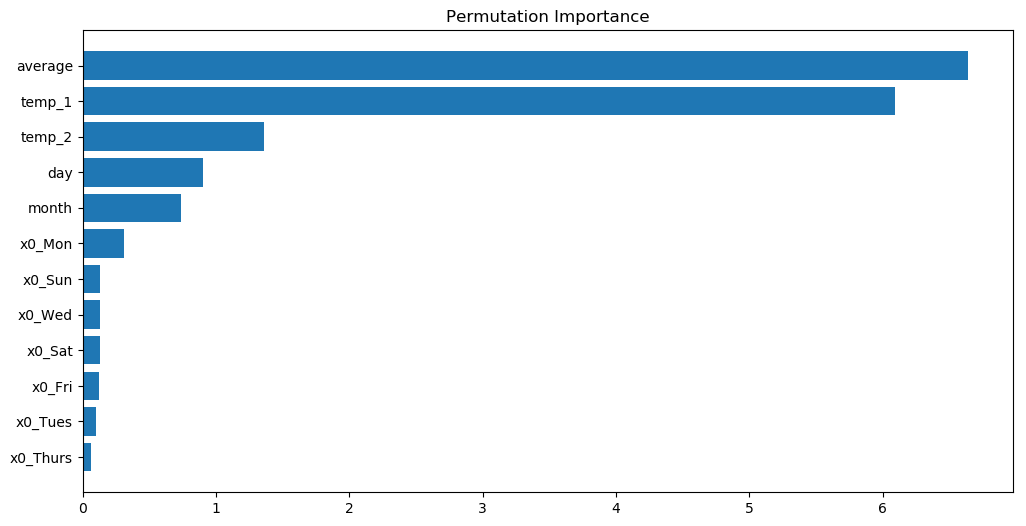

In [20]:
from sklearn.inspection import permutation_importance

feature_importances = permutation_importance(
    RandomForest_search, train_X, train_y, n_repeats=10, random_state=42
)

features = train_X.columns
importances = feature_importances.importances_mean


sorted_idx = feature_importances.importances_mean.argsort()
fig = plt.figure(figsize=(12, 6));
plt.barh(range(len(sorted_idx)), feature_importances.importances_mean[sorted_idx], align='center');
plt.yticks(range(len(sorted_idx)), np.array(train_X.columns)[sorted_idx]);
plt.title('Permutation Importance');
plt.show();

**2. SVM 모델을 적합하시오(15점).**

-   예측한계선을 설정
-   하이퍼 파라미터 튜닝\
-   변수중요도 시각화

In [21]:
from sklearn.svm import SVR
svm_pipe = Pipeline(
    [
        ("regressor", SVR())
    ]
)

SVR_param = {'regressor__C': np.arange(1, 100, 20)}

SVR_search = GridSearchCV(estimator = svm_pipe, 
                      param_grid = SVR_param, 
                      cv = cv,
                      #cv = 5, # KFold 5
                      scoring = 'neg_root_mean_squared_error')
SVR_search.fit(train_X, train_y)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('regressor', SVR())]),
             param_grid={'regressor__C': array([ 1, 21, 41, 61, 81])},
             scoring='neg_root_mean_squared_error')

In [22]:
from sklearn.metrics import mean_squared_error
print('Ramdom forest best parameters : ', SVR_search.best_params_)
print('Random forest best score : ', -SVR_search.best_score_)

print('예측한계선 RMSE :', mean_squared_error(train_y, dat.iloc[train_X.index, :]['average'], squared = False))

Ramdom forest best parameters :  {'regressor__C': 21}
Random forest best score :  5.818465799450394
예측한계선 RMSE : 6.819504929392925


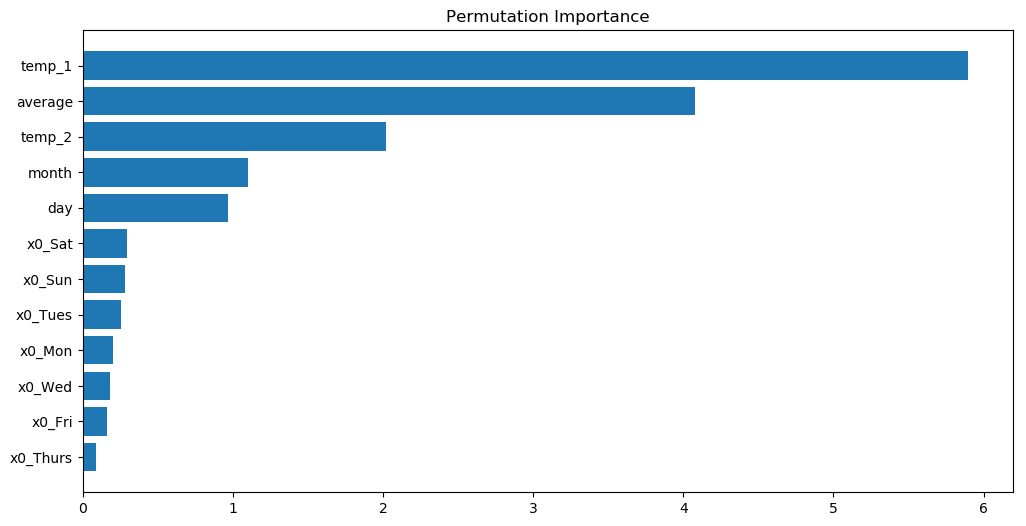

In [23]:
from sklearn.inspection import permutation_importance

feature_importances = permutation_importance(
    SVR_search, train_X, train_y, n_repeats=10, random_state=42
)

features = train_X.columns
importances = feature_importances.importances_mean


sorted_idx = feature_importances.importances_mean.argsort()
fig = plt.figure(figsize=(12, 6));
plt.barh(range(len(sorted_idx)), feature_importances.importances_mean[sorted_idx], align='center');
plt.yticks(range(len(sorted_idx)), np.array(train_X.columns)[sorted_idx]);
plt.title('Permutation Importance');
plt.show();

**3. 두 모델 중 최적의 모델을 선택하시오.**

-   Random forest, SVM 모델 결과 비교 후 최종 모델 선택
-   두 모델의 장·단점 기술
-   운영 관점에서 어떤 모델을 선택할 것인지 기술
-   모델링 관련 개선 방향 제시
**모형 선택**

-   RMSE 기준으로 ramdom forest 모델을 선택

In [24]:
pred = RandomForest_search.predict(test_X)

print('예측한계선 RMSE :', mean_squared_error(pred, test_y, squared = False))

예측한계선 RMSE : 4.895921334568777


최종 검증 데이터에서의 성능은 RMSE = 4.89 정도인 것을 확인할 수 있다.


**SVM**

![](images/clipboard-1881406120.png)

**Random forest**

![](images/clipboard-1100734234.png)

-   운영 관점에서 모형의 성능이 좋은 Random forest 모델 선택

-   속도 관점에서도 비교해볼 수 있음

-   xgboost, lightgbm 같은 부스팅 모형을 함께 앙상블한다면 모형의 성능을 높일 수 있음

## 문제 2

**Data description**

7주 동안의 전력 소비량 데이터(15분 간격으로 측정)입니다.

-   year
-   month
-   day
-   가구코드
-   전력사용량

**1. 군집분석을 실시 후 아래 표를 완성하시오(군집 5개로 고정)(10점).**

![](images/clipboard-4268439827.png)

In [25]:
dat = pd.read_csv('problem2.csv')
dat['date'] = pd.to_datetime(dat['date'])

**clustering**


In [26]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 5)
kmeans.fit(dat['power'].to_numpy().reshape(-1, 1))
label = kmeans.labels_
dat['cluster'] = label
dat.head()

,VID,date,year,month,day,power,cluster
0,7855756,2015-01-01 00:00:00,2015,1,1,0.03,0
1,7855756,2015-01-01 00:15:00,2015,1,1,0.68,4
2,7855756,2015-01-01 00:30:00,2015,1,1,0.57,4
3,7855756,2015-01-01 00:45:00,2015,1,1,0.03,0
4,7855756,2015-01-01 01:00:00,2015,1,1,1.16,4


**2. 각 군집별로 heatmap을 그리시오(총 5개 heatmap 생성)(15점).**

3번 군집에 대한 히트맵은 다음과 같다.

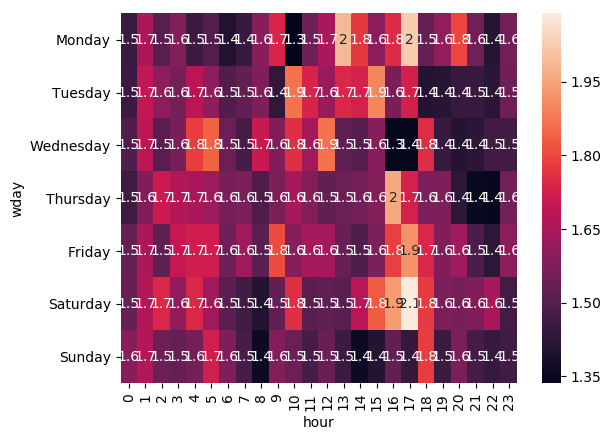

In [27]:
dat['wday'] = dat['date'].dt.day_name()
dat['hour'] = dat['date'].dt.hour


cluster1 = (dat
    .loc[dat.cluster == 1]
    .groupby(['wday', 'hour'])
    .agg(mean_w = ('power', 'mean'))
    .reset_index()
)

cluster1 = cluster1.pivot(index = 'wday', columns = 'hour', values = 'mean_w')

week_or = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

cluster1 = cluster1.loc[week_or]

sns.heatmap(cluster1,annot = True);
plt.show();

나머지 군집 시각화는 동일하므로 생략

## 문제 3

**Data description**

캘리포니아 주에서 재생 가능 에너지원별로 시간별 에너지 생산량을 기록한 데이터입니다.

-   TIMESTAMP: 시간 정보
-   BIOGAS: 바이오가스를 사용하여 생산된 전력량
-   BIOMASS: 바이오매스를 연료로 사용하여 생산된 전력량
-   GEOTHERMAL: 지열 에너지를 이용하여 생산된 전력량
-   Hour: 에너지 생산량이 기록된 시각
-   SMALL HYDRO: 소규모 수력 발전에서 생산된 전력량
-   SOLAR: 태양 에너지로부터 생산된 전력량의 총합
-   SOLAR THERMAL: 태양열 발전을 이용하여 생산된 전력량
-   WIND TOTAL: 풍력 발전으로부터 생성된 총 전력량
-   SOLAR PV(타겟): 태양광 발전(PV, Photovoltaic)을 이용하여 생산된 전력량

**다음 단계를 통해 최종 분석 결과를 제출하시오.**

-   데이터셋 7:3 분할

-   데이터 전처리 및 예측 모델 생성

-   모델 성능 검증 : RMSE, R제곱, 정확도(아래 방식으로 연산)로 구하여라

-   정확도의 경우 실제값\>예측값인 경우 (1-예측값/실제값), 실제값\<예측값인 경우 (1- 실제값/예측값)으로 하고 이것들을 평균낸 후 1에서 뺀값으로 한다.\
    분수식의 분모가 0인 경우의 정확도는 0.5로 취급한다.

-   최종 결과 제출 : 소수점 3째자리 반올림

In [28]:
dat = pd.read_csv('problem3.csv')

In [29]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44904 entries, 0 to 44903
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TIMESTAMP      44904 non-null  object 
 1   BIOGAS         44904 non-null  float64
 2   BIOMASS        44904 non-null  float64
 3   GEOTHERMAL     44904 non-null  float64
 4   Hour           44904 non-null  float64
 5   SMALL HYDRO    44904 non-null  float64
 6   SOLAR          0 non-null      float64
 7   SOLAR PV       44904 non-null  float64
 8   SOLAR THERMAL  44904 non-null  float64
 9   WIND TOTAL     44904 non-null  float64
dtypes: float64(9), object(1)
memory usage: 3.4+ MB


In [30]:
dat.columns = dat.columns.str.strip().str.lower().str.replace(' ', '_')

In [31]:
dat.isna().sum()

timestamp            0
biogas               0
biomass              0
geothermal           0
hour                 0
small_hydro          0
solar            44904
solar_pv             0
solar_thermal        0
wind_total           0
dtype: int64

SOLAR 변수는 모든 값이 결측치이므로, 제거한다.

In [32]:
dat = dat.drop(['solar'], axis = 1)

데이터를 7:3으로 분할한다. 시계열 특성을 반영하여 날짜순으로 데이터를 분할한다.

In [33]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

In [34]:
X = dat.drop(columns=['solar_pv', 'timestamp'])
y = dat['solar_pv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123, shuffle=False)

변수 간 스케일을 통일하고, 각 변수의 중요도를 균등하게 반영하기 위해 표준화를 진행한다. SVM 모델의 경우 거리 기반 알고리즘이므로, 표준화를 통해 예측 성능을 향상시킬 수 있다. Support vector regression 모델을 적합한다.

In [35]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('svr', SVR(kernel='poly'))    
])

param_grid = {
    'svr__C': [0.01, 0.1, 10, 100, 1000] 
}

grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svr', SVR(kernel='poly'))]),
             param_grid={'svr__C': [0.01, 0.1, 10, 100, 1000]},
             scoring='neg_mean_squared_error')

In [36]:
y_pred = grid_search.predict(X_test)

예측 값이 음수가 나오는 경우 0으로 변환

In [37]:
y_pred = np.where(y_pred < 0, 0, y_pred)

-   RMSE

In [38]:
rmse = mean_squared_error(y_test, y_pred, squared=False)
print('RMSE:', rmse)

RMSE: 2386.0652173198155


-   결정계수

In [39]:
r2 = r2_score(y_test, y_pred)
print('R2:', r2)

R2: 0.4508938974649723


-   정확도

In [40]:
def accuracy_function(actual, predicted):
    if actual == 0 or predicted == 0:
        return 0.5
    elif actual > predicted:
        return 1 - (predicted / actual)
    else:
        return 1 - (actual / predicted)

In [41]:
accuracies = [accuracy_function(actual, pred) for actual, pred in zip(y_test, y_pred)]

result = 1 - np.mean(accuracies)
print('Result:', result)

Result: 0.4793214392616667


최종 예측 결과 제출

In [42]:
final_pred = np.round(y_pred, 2)
result_df = pd.DataFrame({'pred': final_pred})
print(result_df.head(2))

      pred
0  7939.63
1  7007.36


In [43]:
#| eval: false
result_df.to_csv('result.csv', index=False)